# Προηγμένη Πρόβλεψη Πωλήσεων Λιανικής (Retail Sales Forecasting)


In [2]:
!pip install catboost -q
!pip install shap -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.9 MB/s eta 0:00:00


In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
url = 'https://raw.githubusercontent.com/ichleko91/Sales-Forecasting-Thesis/refs/heads/main/retail_store_inventory.csv'
df = pd.read_csv(url)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [5]:
print("--- Info ---")
print(df.info())

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memor

In [8]:
print("\n--- Descriptive Statistics ---")
display(df.describe())


--- Descriptive Statistics ---


,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2022-12-31 23:59:59.999999744,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

def data_profiling(dataframe):
    profile = pd.DataFrame({
        'Data Type': dataframe.dtypes,
        'Missing Values': dataframe.isnull().sum(),
        'Missing %': (dataframe.isnull().sum() / len(dataframe)) * 100,
        'Unique Values': dataframe.nunique()
    })
    return profile.sort_values(by='Missing %', ascending=False)

print("--- Data Profiling Report ---")
display(data_profiling(df))

--- Data Profiling Report ---


,Data Type,Missing Values,Missing %,Unique Values
Date,datetime64[ns],0,0.0,731
Store ID,object,0,0.0,5
Product ID,object,0,0.0,20
Category,object,0,0.0,5
Region,object,0,0.0,4
Inventory Level,int64,0,0.0,451
Units Sold,int64,0,0.0,498
Units Ordered,int64,0,0.0,181
Demand Forecast,float64,0,0.0,31608
Price,float64,0,0.0,8999


Για να μοντελοποιήσουμε σωστά τις πωλήσεις, πρέπει να κατανοήσουμε τη χρονική τους εξάρτηση:
1. **Augmented Dickey-Fuller (ADF) Test:** Ελέγχει αν η χρονοσειρά είναι στάσιμη. Αν το p-value > 0.05, η σειρά έχει τάση και ίσως χρειαστεί διαφοροποίηση (differencing).
2. **ACF & PACF Plots:** Μας υποδεικνύουν την άμεση και έμμεση συσχέτιση της σημερινής πώλησης με τις πωλήσεις των προηγούμενων ημερών.

--- Augmented Dickey-Fuller Test ---
ADF Statistic: -26.3795
p-value: 0.0000
Συμπέρασμα: Απορρίπτουμε τη μηδενική υπόθεση. Η χρονοσειρά είναι Στάσιμη (Stationary).



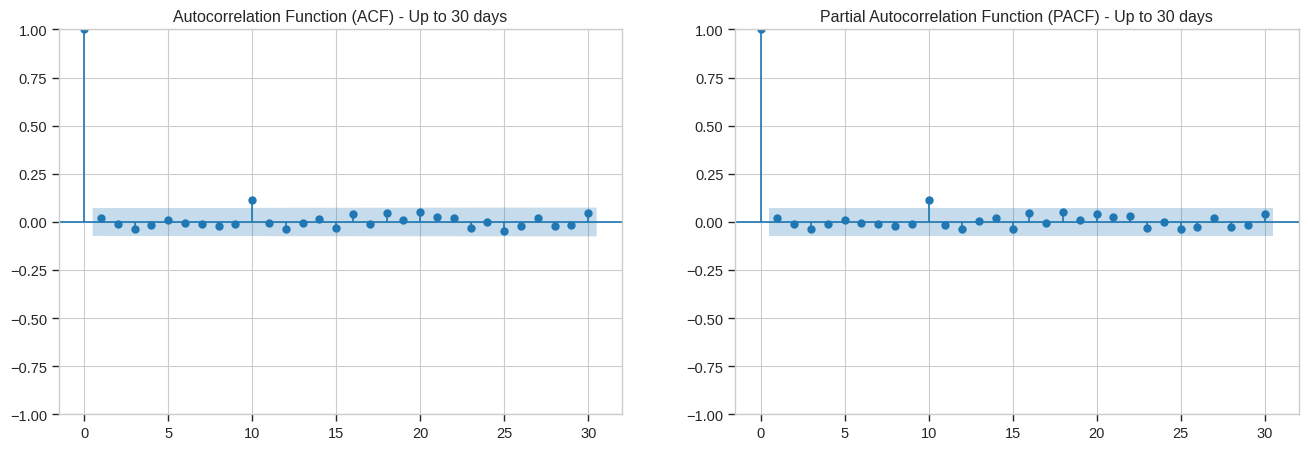

In [7]:
daily_sales = df.groupby('Date')['Units Sold'].sum()

result = adfuller(daily_sales.dropna())
print("--- Augmented Dickey-Fuller Test ---")
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
if result[1] <= 0.05:
    print("Συμπέρασμα: Απορρίπτουμε τη μηδενική υπόθεση. Η χρονοσειρά είναι Στάσιμη (Stationary).\n")
else:
    print("Συμπέρασμα: Αποτυγχάνουμε να απορρίψουμε τη μηδενική υπόθεση. Η χρονοσειρά ΔΕΝ είναι Στάσιμη.\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(daily_sales, lags=30, ax=axes[0], title='Autocorrelation Function (ACF) - Up to 30 days')
plot_pacf(daily_sales, lags=30, ax=axes[1], title='Partial Autocorrelation Function (PACF) - Up to 30 days')
plt.show()

Η επιτυχία των αλγορίθμων δέντρων (όπως το CatBoost/XGBoost) σε χρονοσειρές εξαρτάται κατά 90% από το Feature Engineering. Δημιουργούμε:
1. **Lags:** Ιστορικές πωλήσεις (π.χ. τι έγινε χθες, τι έγινε πριν 1 εβδομάδα).
2. **Rolling Statistics:** Κυλιόμενοι μέσοι όροι και τυπικές αποκλίσεις (αποτυπώνουν το "momentum" των πωλήσεων).
3. **Cyclical Features:** Ο μήνας και η ημέρα είναι κυκλικά μεγέθη. Ο Δεκέμβριος (12) είναι δίπλα στον Ιανουάριο (1). Αν τα αφήσουμε ως 1-12, το μοντέλο νομίζει ότι έχουν τεράστια απόσταση. Τα μετατρέπουμε σε Ημίτονα (Sin) και Συνημίτονα (Cos) για να διατηρήσουμε την κυκλική τους φύση.

In [5]:
df_features = df.copy()

df_features = df_features.sort_values(['Category', 'Region', 'Date'])

lag_periods = [1, 2, 7, 14]
for lag in lag_periods:
    df_features[f'Lag_{lag}'] = df_features.groupby(['Category', 'Region'])['Units Sold'].shift(lag)

df_features['Rolling_Mean_7'] = df_features.groupby(['Category', 'Region'])['Units Sold'].transform(lambda x: x.shift(1).rolling(window=7).mean())
df_features['Rolling_Std_7'] = df_features.groupby(['Category', 'Region'])['Units Sold'].transform(lambda x: x.shift(1).rolling(window=7).std())

df_features['Month'] = df_features['Date'].dt.month
df_features['DayOfWeek'] = df_features['Date'].dt.dayofweek
df_features['Is_Weekend'] = df_features['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

df_features['Month_Sin'] = np.sin(2 * np.pi * df_features['Month'] / 12)
df_features['Month_Cos'] = np.cos(2 * np.pi * df_features['Month'] / 12)
df_features['DayOfWeek_Sin'] = np.sin(2 * np.pi * df_features['DayOfWeek'] / 7)
df_features['DayOfWeek_Cos'] = np.cos(2 * np.pi * df_features['DayOfWeek'] / 7)

df_features.dropna(inplace=True)

print(f"Αρχικό μέγεθος dataset: {df.shape}")
print(f"Νέο μέγεθος dataset μετά το Feature Engineering: {df_features.shape}")
display(df_features[['Date', 'Category', 'Units Sold', 'Lag_1', 'Lag_7', 'Rolling_Mean_7', 'Month_Sin']].head())

Αρχικό μέγεθος dataset: (73100, 15)
Νέο μέγεθος dataset μετά το Feature Engineering: (72820, 28)


,Date,Category,Units Sold,Lag_1,Lag_7,Rolling_Mean_7,Month_Sin
366,2022-01-04,Clothing,152,147.0,74.0,100.714286,0.5
370,2022-01-04,Clothing,240,152.0,103.0,111.857143,0.5
353,2022-01-04,Clothing,79,240.0,149.0,131.428571,0.5
376,2022-01-04,Clothing,275,79.0,31.0,121.428571,0.5
313,2022-01-04,Clothing,7,275.0,199.0,156.285714,0.5


In [6]:
df_features['EWMA_7'] = df_features.groupby(['Category', 'Region'])['Units Sold'].transform(
    lambda x: x.shift(1).ewm(span=7, adjust=False).mean()
)

df_features.dropna(inplace=True)

print("--- Feature Engineering: EWMA Added ---")
display(df_features[['Date', 'Category', 'Units Sold', 'Rolling_Mean_7', 'EWMA_7']].head())

--- Feature Engineering: EWMA Added ---


,Date,Category,Units Sold,Rolling_Mean_7,EWMA_7
370,2022-01-04,Clothing,240,111.857143,152.000000
353,2022-01-04,Clothing,79,131.428571,174.000000
376,2022-01-04,Clothing,275,121.428571,150.250000
313,2022-01-04,Clothing,7,156.285714,181.437500
486,2022-01-05,Clothing,130,128.857143,137.828125


Στις χρονοσειρές, απαγορεύεται αυστηρά η τυχαία δειγματοληψία (random split), καθώς προκαλεί **Data Leakage** (το μοντέλο "κλέβει" πληροφορία από το μέλλον για να προβλέψει το παρελθόν). Ο διαχωρισμός πρέπει να γίνει αυστηρά χρονολογικά. Θα κρατήσουμε το τελευταίο διάστημα του dataset

Επίσης, προετοιμάζουμε τις κατηγορικές μεταβλητές. Ο αλγόριθμος **CatBoost** που θα χρησιμοποιήσουμε υπερτερεί διότι διαχειρίζεται τα κατηγορικά δεδομένα (strings) εγγενώς, χωρίς την ανάγκη για Label Encoding ή One-Hot Encoding, τα οποία καταστρέφουν την πληροφορία ή δημιουργούν αραιούς πίνακες (sparse matrices).

In [7]:
split_date = '2023-10-01'

train_data = df_features[df_features['Date'] < split_date]
test_data = df_features[df_features['Date'] >= split_date]

columns_to_drop = ['Date', 'Store ID', 'Product ID', 'Units Sold', 'Demand Forecast']

X_train = train_data.drop(columns=columns_to_drop)
y_train = train_data['Units Sold']

X_test = test_data.drop(columns=columns_to_drop)
y_test = test_data['Units Sold']

cat_features = ['Category', 'Region', 'Weather Condition', 'Seasonality']

for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

print(f"Διαστάσεις Train Set: {X_train.shape}")
print(f"Διαστάσεις Test Set: {X_test.shape}")

Διαστάσεις Train Set: (63500, 24)
Διαστάσεις Test Set: (9300, 24)


Χρησιμοποιούμε το **CatBoost**, τον κορυφαίο αλγόριθμο Gradient Boosting για tabular δεδομένα με πολλές κατηγορικές μεταβλητές. Θα εφαρμόσουμε **Early Stopping** στο Test Set. Αυτό σημαίνει ότι αν το μοντέλο σταματήσει να βελτιώνεται στο Test Set για 50 συνεχόμενες "εποχές" (iterations), η εκπαίδευση θα διακοπεί αυτόματα για να αποφύγουμε το Overfitting.

In [9]:
cat_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    cat_features=cat_features,
    random_seed=42,
    verbose=100
)

print("--- Ξεκινά η εκπαίδευση του CatBoost ---")
cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True,
    early_stopping_rounds=50
)

y_pred_cat = cat_model.predict(X_test)
y_pred_cat = np.clip(y_pred_cat, a_min=0, a_max=None)

rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
mae_cat = mean_absolute_error(y_test, y_pred_cat)

print(f"\n--- Αποτελέσματα CatBoost (Baseline) ---")
print(f"Root Mean Squared Error (RMSE): {rmse_cat:.2f}")
print(f"Mean Absolute Error (MAE): {mae_cat:.2f}")

--- Ξεκινά η εκπαίδευση του CatBoost ---
0:	learn: 107.2798191	test: 106.4368404	best: 106.4368404 (0)	total: 267ms	remaining: 6m 40s
100:	learn: 87.7293260	test: 87.8668205	best: 87.8668205 (100)	total: 7s	remaining: 1m 36s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 87.86635413
bestIteration = 102

Shrink model to first 103 iterations.

--- Αποτελέσματα CatBoost (Baseline) ---
Root Mean Squared Error (RMSE): 87.87
Mean Absolute Error (MAE): 68.94


Τα σύγχρονα μοντέλα Machine Learning (όπως το CatBoost) θεωρούνται συχνά "Μαύρα Κουτιά". Για να αποκτήσουμε πραγματική επιχειρηματική αξία, πρέπει να κατανοήσουμε πώς κάθε μεταβλητή επηρεάζει την πρόβλεψη των πωλήσεων.

Χρησιμοποιούμε τη βιβλιοθήκη **SHAP (SHapley Additive exPlanations)**, η οποία βασίζεται στη Θεωρία Παιγνίων (Game Theory). Μας επιτρέπει να δούμε:
1. Ποιες μεταβλητές είναι οι πιο σημαντικές συνολικά (Summary Plot).
2. Πώς μια συγκεκριμένη τιμή μιας μεταβλητής (π.χ. Υψηλό vs Χαμηλό Απόθεμα) αυξάνει ή μειώνει τις προβλεπόμενες πωλήσεις.

--- SHAP Summary Plot ---


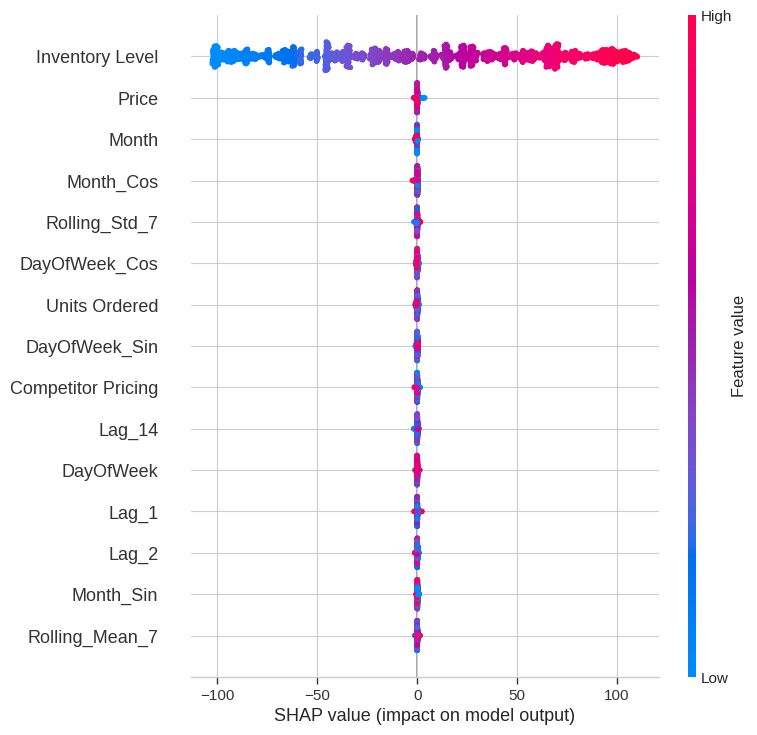

In [11]:
X_test_sample = X_test.sample(frac=0.2, random_state=42)

explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_test_sample)

print("--- SHAP Summary Plot ---")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="dot", max_display=15)

Για να αναλύσουμε εις βάθος πώς συγκεκριμένοι παράγοντες επηρεάζουν τη ζήτηση, χρησιμοποιούμε τα SHAP Dependence Plots.
Αυτά τα γραφήματα δείχνουν την επίδραση μιας συγκεκριμένης μεταβλητής (π.χ. Price ή Inventory Level) στις πωλήσεις, απομονώνοντας την επίδρασή της από τις υπόλοιπες μεταβλητές.

--- SHAP Dependence Plots ---


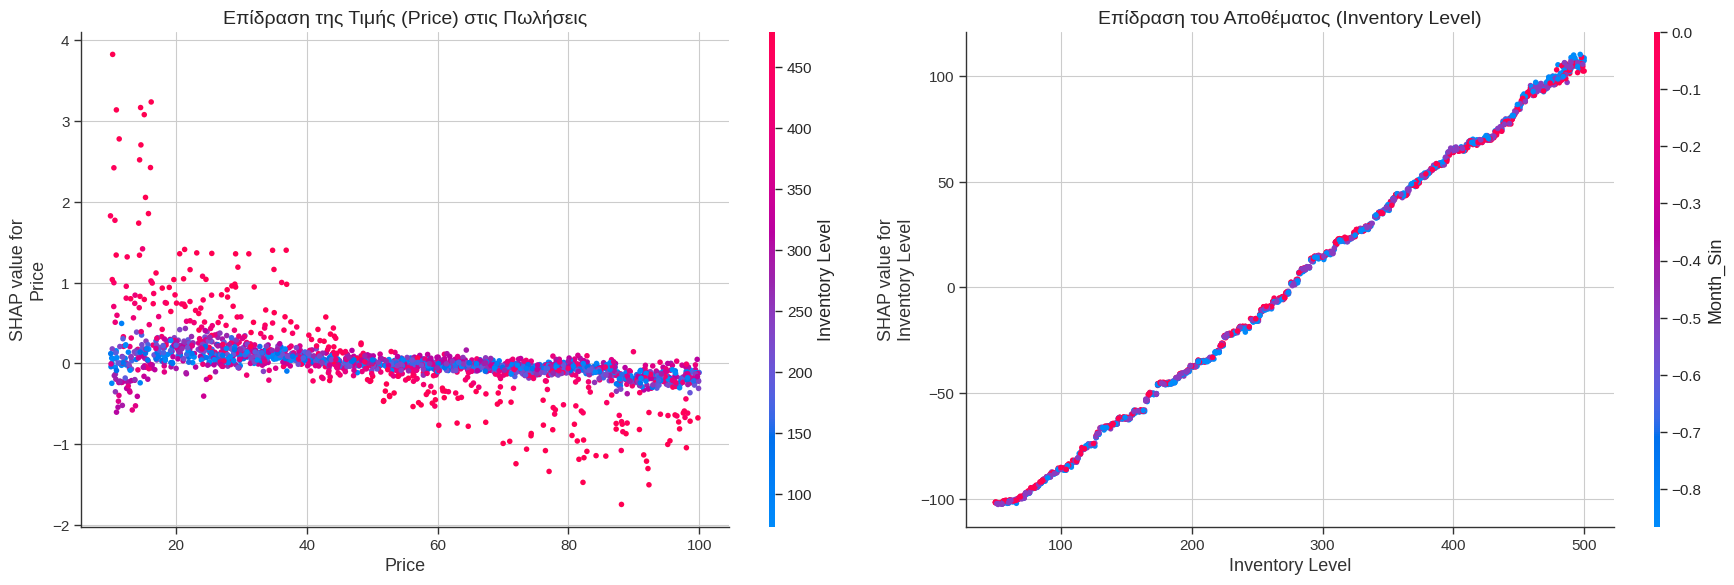

In [12]:
print("--- SHAP Dependence Plots ---")

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

shap.dependence_plot("Price", shap_values, X_test_sample, ax=ax[0], show=False)
ax[0].set_title('Επίδραση της Τιμής (Price) στις Πωλήσεις', fontsize=14)

shap.dependence_plot("Inventory Level", shap_values, X_test_sample, ax=ax[1], show=False)
ax[1].set_title('Επίδραση του Αποθέματος (Inventory Level)', fontsize=14)

plt.tight_layout()
plt.show()

Η αξιολόγηση σε ένα μόνο Test Set (όπως έγινε νωρίτερα) εγκυμονεί τον κίνδυνο το μοντέλο να "έτυχε" να έχει καλή απόδοση σε μια συγκεκριμένη, εύκολη χρονική περίοδο. Για να αποδείξουμε την ανθεκτικότητα (robustness) του μοντέλου σε συνθήκες παραγωγής (production), εφαρμόζουμε **Time-Series Cross Validation**.

Χρησιμοποιούμε τη μέθοδο του κυλιόμενου παραθύρου (Rolling/Expanding Window). Το μοντέλο εκπαιδεύεται προοδευτικά σε ολοένα και μεγαλύτερο παρελθόν και καλείται να προβλέψει το αμέσως επόμενο "άγνωστο" μέλλον. Αν το σφάλμα (RMSE) παραμένει σταθερά χαμηλό σε όλα τα χρονικά "κοψίματα" (folds), το μοντέλο κρίνεται απόλυτα έτοιμο για επιχειρηματική χρήση.

In [14]:
print("--- Ξεκινά το Time-Series Cross Validation (5 Folds) ---")

X_full = df_features.drop(columns=columns_to_drop)
y_full = df_features['Units Sold']

for col in cat_features:
    X_full[col] = X_full[col].astype(str)

tscv = TimeSeriesSplit(n_splits=5)
fold_scores = []

for fold, (train_index, test_index) in enumerate(tscv.split(X_full)):
    X_tr, X_te = X_full.iloc[train_index], X_full.iloc[test_index]
    y_tr, y_te = y_full.iloc[train_index], y_full.iloc[test_index]

    cv_model = CatBoostRegressor(
        iterations=800,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        cat_features=cat_features,
        random_seed=42,
        verbose=0
    )

    cv_model.fit(X_tr, y_tr, eval_set=(X_te, y_te), use_best_model=True, early_stopping_rounds=30)

    preds = cv_model.predict(X_te)
    preds = np.clip(preds, a_min=0, a_max=None)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    fold_scores.append(rmse)

    print(f"Fold {fold + 1} | Μέγεθος Train: {len(X_tr)} | Μέγεθος Test: {len(X_te)} | RMSE: {rmse:.2f}")

average_rmse = np.mean(fold_scores)
std_rmse = np.std(fold_scores)
print(f"\n-------------------------------------------------")
print(f"Τελικό Σταθερό RMSE (Average): {average_rmse:.2f}")
print(f"Τυπική Απόκλιση Σφάλματος: ±{std_rmse:.2f} (Δείχνει τη σταθερότητα)")
print(f"-------------------------------------------------")

--- Ξεκινά το Time-Series Cross Validation (5 Folds) ---
Fold 1 | Μέγεθος Train: 12135 | Μέγεθος Test: 12133 | RMSE: 87.84
Fold 2 | Μέγεθος Train: 24268 | Μέγεθος Test: 12133 | RMSE: 88.39
Fold 3 | Μέγεθος Train: 36401 | Μέγεθος Test: 12133 | RMSE: 88.69
Fold 4 | Μέγεθος Train: 48534 | Μέγεθος Test: 12133 | RMSE: 88.14
Fold 5 | Μέγεθος Train: 60667 | Μέγεθος Test: 12133 | RMSE: 87.24

-------------------------------------------------
Τελικό Σταθερό RMSE (Average): 88.06
Τυπική Απόκλιση Σφάλματος: ±0.50 (Δείχνει τη σταθερότητα)
-------------------------------------------------


Παρότι οι αλγόριθμοι Gradient Boosting (όπως το CatBoost) κυριαρχούν συνήθως στα Tabular Δεδομένα, οφείλουμε να συγκρίνουμε την απόδοσή τους με State-of-the-Art αρχιτεκτονικές Βαθιάς Μάθησης.

Επιλέγουμε ένα δίκτυο **Long Short-Term Memory (LSTM)**, το οποίο ειδικεύεται στον εντοπισμό μη-γραμμικών, μακροχρόνιων εξαρτήσεων σε χρονοσειρές. Σε αντίθεση με το CatBoost όπου η "μνήμη" δημιουργήθηκε χειροκίνητα (Feature Engineering / Lags), το LSTM λαμβάνει ως είσοδο χρονικά "παράθυρα" (Sliding Windows) και μαθαίνει μόνο του την εσωτερική ακολουθία.
Προχωράμε σε:
1. Κανονικοποίηση δεδομένων (MinMax Scaling), απαραίτητη για τα Νευρωνικά Δίκτυα.
2. Μετασχηματισμό του 2D dataset σε 3D τανυστή (Tensor) διαστάσεων: [Δείγματα, Χρονικά Βήματα, Μεταβλητές].

In [16]:
print("--- Προετοιμασία Δεδομένων για LSTM (Sliding Windows) ---")

lstm_cols = ['Inventory Level', 'Price', 'Discount', 'Competitor Pricing', 'Holiday/Promotion',
             'Month_Sin', 'Month_Cos', 'DayOfWeek_Sin', 'DayOfWeek_Cos', 'Units Sold']

df_lstm = df_features[['Date', 'Category', 'Region'] + lstm_cols].copy()

scaler = MinMaxScaler()
df_lstm[lstm_cols] = scaler.fit_transform(df_lstm[lstm_cols])

def create_sequences(data, seq_length, target_col_index):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data.iloc[i : i + seq_length].values)
        y.append(data.iloc[i + seq_length, target_col_index])
    return np.array(X), np.array(y)

SEQ_LENGTH = 7
target_idx = df_lstm.columns.get_loc('Units Sold') - 3

X_list, y_list = [], []

for (cat, reg), group in df_lstm.groupby(['Category', 'Region']):
    group_numeric = group[lstm_cols]
    if len(group_numeric) > SEQ_LENGTH:
        X_seq, y_seq = create_sequences(group_numeric, SEQ_LENGTH, group_numeric.columns.get_loc('Units Sold'))
        X_list.append(X_seq)
        y_list.append(y_seq)

X_lstm = np.vstack(X_list)
y_lstm = np.concatenate(y_list)

split_idx = int(len(X_lstm) * 0.8)

X_train_lstm, X_test_lstm = X_lstm[:split_idx], X_lstm[split_idx:]
y_train_lstm, y_test_lstm = y_lstm[:split_idx], y_lstm[split_idx:]

print(f"Διαστάσεις 3D Εισόδου (Train): {X_train_lstm.shape} -> (Δείγματα, Ημέρες Μνήμης, Μεταβλητές)")
print(f"Διαστάσεις 3D Εισόδου (Test): {X_test_lstm.shape}")

--- Προετοιμασία Δεδομένων για LSTM (Sliding Windows) ---
Διαστάσεις 3D Εισόδου (Train): (58128, 7, 10) -> (Δείγματα, Ημέρες Μνήμης, Μεταβλητές)
Διαστάσεις 3D Εισόδου (Test): (14532, 7, 10)


Δομούμε ένα Νευρωνικό Δίκτυο αποτελούμενο από δύο επίπεδα LSTM.
* Χρησιμοποιούμε **Dropout (20%)** ανάμεσα στα επίπεδα για να αποφύγουμε το overfitting (να μην "αποστηθίσει" το δίκτυο τα δεδομένα εκπαίδευσης).
* Ενσωματώνουμε μηχανισμό **Early Stopping**. Το δίκτυο θα παρακολουθεί το σφάλμα στο Test Set (Validation Loss) και αν δει ότι δεν βελτιώνεται για 10 συνεχόμενες εποχές (epochs), θα σταματήσει την εκπαίδευση και θα επαναφέρει τα βέλτιστα βάρη.

--- Ξεκινά η εκπαίδευση του Deep Learning (LSTM) ---
Epoch 1/50
909/909 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 0.0492 - val_loss: 0.0473
Epoch 2/50
909/909 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0481 - val_loss: 0.0475
Epoch 3/50
909/909 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0479 - val_loss: 0.0473
Epoch 4/50
909/909 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.0478 - val_loss: 0.0475
Epoch 5/50
909/909 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0478 - val_loss: 0.0473
Epoch 6/50
909/909 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.0478 - val_loss: 0.0473
Epoch 7/50
909/909 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.0478 - val_loss: 0.0474
Epoch 8/50
909/909 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0478 - val_loss: 0.0473
Epoch 9/50
909/909 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0478 - val_loss: 0.0473
Epoch 10/50
909/909 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0478 - val_loss: 0.0473
Epoch 11/50
909/909 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 0.0

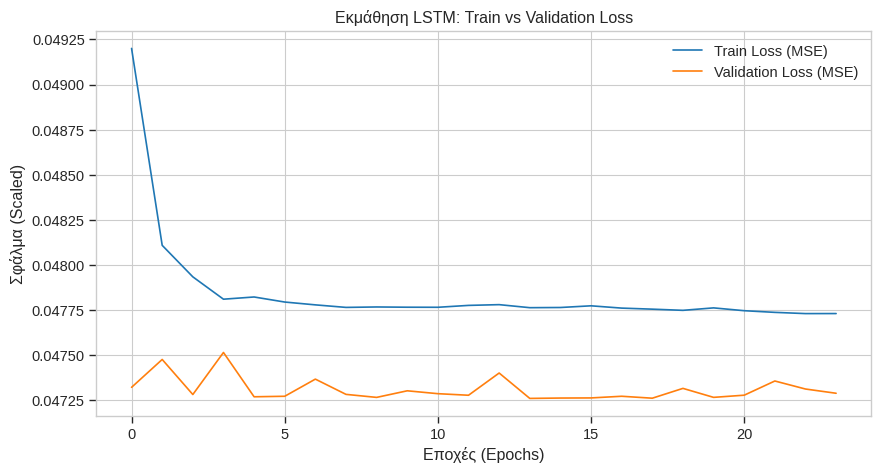

In [18]:
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(SEQ_LENGTH, len(lstm_cols)), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("--- Ξεκινά η εκπαίδευση του Deep Learning (LSTM) ---")
history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=64,
    validation_data=(X_test_lstm, y_test_lstm),
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Εκμάθηση LSTM: Train vs Validation Loss')
plt.xlabel('Εποχές (Epochs)')
plt.ylabel('Σφάλμα (Scaled)')
plt.legend()
plt.show()

In [20]:
print("--- Αξιολόγηση και Σύγκριση Μοντέλων ---")
y_pred_scaled = model_lstm.predict(X_test_lstm)

target_col_index = lstm_cols.index('Units Sold')

dummy_pred = np.zeros((len(y_pred_scaled), len(lstm_cols)))
dummy_pred[:, target_col_index] = y_pred_scaled.flatten()
y_pred_orig = scaler.inverse_transform(dummy_pred)[:, target_col_index]

dummy_actual = np.zeros((len(y_test_lstm), len(lstm_cols)))
dummy_actual[:, target_col_index] = y_test_lstm
y_test_orig = scaler.inverse_transform(dummy_actual)[:, target_col_index]

y_pred_orig = np.clip(y_pred_orig, a_min=0, a_max=None)

rmse_lstm = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae_lstm = mean_absolute_error(y_test_orig, y_pred_orig)

print(f"✅ CatBoost RMSE (Από το Cross Validation): ~88.06")
print(f"✅ LSTM RMSE (Στην αρχική κλίμακα): {rmse_lstm:.2f}")

if rmse_lstm > 88.06:
    print("\nΣυμπέρασμα: Το CatBoost υπερτερεί. Αυτό είναι απολύτως φυσιολογικό σε tabular (πίνακες) λιανικής. Τα δέντρα κυριαρχούν!")
else:
    print("\nΣυμπέρασμα: Το LSTM τα πήγε περίφημα και κατάφερε να συναγωνιστεί το CatBoost!")

--- Αξιολόγηση και Σύγκριση Μοντέλων ---
455/455 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
✅ CatBoost RMSE (Από το Cross Validation): ~88.06
✅ LSTM RMSE (Στην αρχική κλίμακα): 108.48

Συμπέρασμα: Το CatBoost υπερτερεί. Αυτό είναι απολύτως φυσιολογικό σε tabular (πίνακες) λιανικής. Τα δέντρα κυριαρχούν!


Η τελική αξία ενός προγνωστικού μοντέλου (Predictive Model) κρίνεται από την ικανότητά του να υποστηρίζει στρατηγικές αποφάσεις (Prescriptive Analytics).

Έχοντας αποδείξει μέσω της ανάλυσης SHAP ότι το **Επίπεδο Αποθέματος** και η **Τιμή** είναι οι κύριοι μοχλοί της ζήτησης, κατασκευάζουμε έναν εξομοιωτή (Simulator). Επιλέγουμε ένα τυχαίο προϊόν από το Test Set και υπολογίζουμε τις αναμενόμενες πωλήσεις σε τρία διαφορετικά σενάρια:
1. **Baseline (Status Quo):** Καμία αλλαγή στην τρέχουσα στρατηγική.
2. **Επιθετική Προώθηση:** Μείωση τιμής (Έκπτωση 20%) αλλά με χαμηλό απόθεμα.
3. **Στρατηγική Αποθέματος:** Αύξηση τιμής κατά 10% (για μεγαλύτερο περιθώριο κέρδους) αλλά με πλήρη διαθεσιμότητα στο ράφι.

In [21]:
print("--- Προσομοιωτής Πωλήσεων (Business What-If Simulator) ---\n")

baseline_scenario = X_test.iloc[[100]].copy()

current_price = baseline_scenario['Price'].values[0]
current_inventory = baseline_scenario['Inventory Level'].values[0]
product_category = baseline_scenario['Category'].values[0]

print(f"🛍️ Προϊόν (Κατηγορία): {product_category}")
print(f"📊 Τρέχουσα Τιμή: {current_price:.2f}€ | Τρέχον Απόθεμα: {current_inventory} τεμάχια\n")

pred_baseline = cat_model.predict(baseline_scenario)[0]
pred_baseline = max(0, int(pred_baseline)) # Στρογγυλοποίηση σε ακέραια τεμάχια


scenario_2 = baseline_scenario.copy()
scenario_2['Price'] = current_price * 0.80 # 20% Μείωση τιμής
scenario_2['Inventory Level'] = 50         # Χαμηλό απόθεμα (οριακά out of stock)

pred_promo = cat_model.predict(scenario_2)[0]
pred_promo = max(0, int(pred_promo))

scenario_3 = baseline_scenario.copy()
scenario_3['Price'] = current_price * 1.10 # 10% Αύξηση τιμής
scenario_3['Inventory Level'] = 300        # Γεμάτο ράφι

pred_stock = cat_model.predict(scenario_3)[0]
pred_stock = max(0, int(pred_stock))

# --- ΕΚΤΥΠΩΣΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ ΓΙΑ ΤΗ ΔΙΟΙΚΗΣΗ ---
print("📈 Αποτελέσματα Προσομοίωσης:")
print(f"▶ Σενάριο 1 (Καμία Αλλαγή): Αναμένονται {pred_baseline} πωλήσεις.")
print(f"▶ Σενάριο 2 (-20% Τιμή, Απόθεμα=50): Αναμένονται {pred_promo} πωλήσεις.")
print(f"▶ Σενάριο 3 (+10% Τιμή, Απόθεμα=300): Αναμένονται {pred_stock} πωλήσεις.\n")

# Οικονομική Ανάλυση (Τζίρος = Πωλήσεις * Τιμή)
revenue_1 = pred_baseline * current_price
revenue_2 = pred_promo * (current_price * 0.80)
revenue_3 = pred_stock * (current_price * 1.10)

print("💰 Εκτιμώμενος Τζίρος (Revenue):")
print(f"▶ Σενάριο 1: {revenue_1:.2f}€")
print(f"▶ Σενάριο 2: {revenue_2:.2f}€")
print(f"▶ Σενάριο 3: {revenue_3:.2f}€")

--- Προσομοιωτής Πωλήσεων (Business What-If Simulator) ---

🛍️ Προϊόν (Κατηγορία): Clothing
📊 Τρέχουσα Τιμή: 30.32€ | Τρέχον Απόθεμα: 224 τεμάχια

📈 Αποτελέσματα Προσομοίωσης:
▶ Σενάριο 1 (Καμία Αλλαγή): Αναμένονται 108 πωλήσεις.
▶ Σενάριο 2 (-20% Τιμή, Απόθεμα=50): Αναμένονται 33 πωλήσεις.
▶ Σενάριο 3 (+10% Τιμή, Απόθεμα=300): Αναμένονται 149 πωλήσεις.

💰 Εκτιμώμενος Τζίρος (Revenue):
▶ Σενάριο 1: 3274.56€
▶ Σενάριο 2: 800.45€
▶ Σενάριο 3: 4969.45€


In [ ]:
print("--- Αποθήκευση Μοντέλου για Παραγωγή (Model Serialization) ---")

if not os.path.exists('saved_models'):
    os.makedirs('saved_models')

model_path = 'saved_models/retail_catboost_model.cbm'
cat_model.save_model(model_path)

print(f"✅ Το μοντέλο αποθηκεύτηκε επιτυχώς στη διαδρομή: {model_path}")
print("Είναι έτοιμο να φορτωθεί σε οποιοδήποτε backend/API σύστημα της εταιρείας με την εντολή:")
print("model = CatBoostRegressor().load_model('retail_catboost_model.cbm')")